In [1]:
## Required python packages
'''
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scipy
!pip install scikit-learn
'''
!pip install gdown
!pip install scikit-network
!pip install scanpy
!pip install infercnvpy
!pip install inferploidy --upgrade
!pip install scoda-viz==0.4.20


  Using cached gdown-5.2.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached PySocks-1.7.1-py3-none-any.whl.metadata (13 kB)
Using cached gdown-5.2.0-py3-none-any.whl (18 kB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
Using cached requests-2.32.5-py3-none-any.whl (64 kB)
Using cached PySocks-1.7.1-py3-none-any.whl (16 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [gdown]m 5/12 [idna]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 11.6 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cache

In [23]:
## Import required packages
import copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import sknetwork
from inferploidy import run_inferploidy, run_infercnv, plot_cnv, load_sample_data
from scodaviz import load_scoda_processed_sample_data, find_condition_specific_markers, plot_marker_exp

warnings.filterwarnings('ignore')

In [24]:
adata = sc.read_h5ad("../../../../data/HGSOC/ALL_CELLS/all_cells_1p.h5ad")

In [25]:
# Get unnormalized gene expression reads
adata = adata.raw.to_adata()

In [4]:
# Prepare data for running InferCNV
adata.obs['tumor_origin_ind'] = adata.obs['cell_type'] == 'fallopian tube secretory epithelial cell'

In [5]:
# GOAL: 
# - Understand what the requirements of InfewrCNV and InferPloidy are 

"""
CHANGES: 
- ADDED A GTF FILE FOR HG19
- Remvoed fallopian (cancerous?) cells from the `ref cat`
   - Concern: Could there be Fallopian tube cell normals? 
"""

'\nCHANGES: \n- ADDED A GTF FILE FOR HG19\n- Remvoed fallopian (cancerous?) cells from the `ref cat`\n   - Concern: Could there be Fallopian tube cell normals? \n'

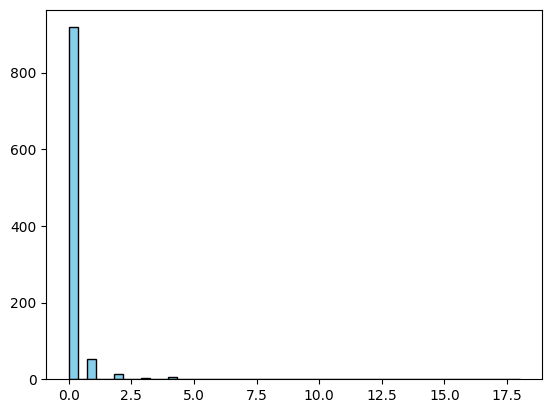

In [6]:
sample = np.random.choice(np.asarray(adata.X.todense()).flatten(), size=1000, replace=False)

# Plot histogram
plt.hist(sample, bins=50, color='skyblue', edgecolor='black')
plt.show()

In [7]:
# TODO - read instruction guide for using below function 
ref_key = 'cell_type'
ref_cat = ['T cell', 'fibroblast', 'monocyte', 'plasma cell', 'dendritic cell', 'endothelial cell', 'B cell', 'mast cell']


In [8]:
run_infercnv(adata, ref_key = ref_key, ref_cat = ref_cat,
             gtf_file = '/Users/jeromecho/onedrive/Thesis/thesis/auxiliary/gtf/hg19_gene_only.gtf', species = 'hs',
             window_size = 1, n_cores = 4 )

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


adata_tmp
AnnData object with n_obs × n_vars = 10199 × 31815
    obs: 'percent.mt', 'percent.rb', 'doublet', 'author_sample_id', 'S.Score', 'G2M.Score', 'Phase', 'CC.Diff', 'author_cell_type', 'nCount_RNA', 'nFeature_RNA', 'doublet_score', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'author_tumor_supersite', 'author_tumor_site', 'author_tumor_subsite', 'author_sort_parameters', 'author_therapy', 'author_procedure', 'author_procedure_type', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'tumor_origin_ind', 'cnv_ref_ind'
    var: 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'chromosome', 'start', 'end', 'gene_name', 'gene_id'
    uns: 'au

100%|███████████████████████████████████████████████████████████████████████| 3/3 [00:03<00:00,  1.19s/it]


AnnData object with n_obs × n_vars = 10199 × 31815
    obs: 'percent.mt', 'percent.rb', 'doublet', 'author_sample_id', 'S.Score', 'G2M.Score', 'Phase', 'CC.Diff', 'author_cell_type', 'nCount_RNA', 'nFeature_RNA', 'doublet_score', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'author_tumor_supersite', 'author_tumor_site', 'author_tumor_subsite', 'author_sort_parameters', 'author_therapy', 'author_procedure', 'author_procedure_type', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'tumor_origin_ind', 'cnv_ref_ind'
    var: 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'chromosome', 'start', 'end', 'gene_id', 'gene_name'
    uns: 'author_cell_

In [9]:
adata.obsm['X_cnv'].todense()

matrix([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(10199, 2925))

In [10]:
ref_key

'cell_type'

In [11]:
ref_cat

['T cell',
 'fibroblast',
 'monocyte',
 'plasma cell',
 'dendritic cell',
 'endothelial cell',
 'B cell',
 'mast cell']

In [12]:
print(adata.obs.columns)
print(adata.obs[ref_key].unique())

Index(['percent.mt', 'percent.rb', 'doublet', 'author_sample_id', 'S.Score',
       'G2M.Score', 'Phase', 'CC.Diff', 'author_cell_type', 'nCount_RNA',
       'nFeature_RNA', 'doublet_score', 'cell_type_ontology_term_id',
       'tissue_ontology_term_id', 'assay_ontology_term_id', 'suspension_type',
       'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id',
       'development_stage_ontology_term_id', 'sex_ontology_term_id',
       'donor_id', 'author_tumor_supersite', 'author_tumor_site',
       'author_tumor_subsite', 'author_sort_parameters', 'author_therapy',
       'author_procedure', 'author_procedure_type', 'is_primary_data',
       'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue',
       'self_reported_ethnicity', 'development_stage', 'observation_joinid',
       'tumor_origin_ind', 'cnv_ref_ind'],
      dtype='object')
['T cell', 'fallopian tube secretory epithelial cell', 'fibroblast', 'monocyte', 'plasma cell', 'dendritic cell', 'endothelial

In [13]:
# TODO - figure out why so many of the fallopian tube cells are being classified as being "unclear" (instead of being either one of 
#        diploid or aneuploid) 


adata = run_inferploidy( adata, ref_key = ref_key, ref_cat = ref_cat,
                         N_runs = 20, n_cores = 4, verbose = True,
                         clustering_resolution = 6 ) 
# Try 6 for Louvain Clustering resolution for now and sanity check against 
# the dataset (details of how to do sanity check TBD). Deep dive if the quality suffers. 

adata.obs['ploidy_dec'] = adata.obs['iploidy_dec']
adata.obs['ploidy_score'] = adata.obs['iploidy_score']
adata.obs['ploidy_init_group'] = adata.obs['iploidy_init_group']

adata

InferPloidy .. 
merged_cluster
[np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(43), np.int64(44), np.int64(46), np.int64(47), np.int64(48), np.int64(50), np.int64(55), np.int64(57), np.int64(59), np.int64(60), np.int64(62), np.int64(64), np.int64(67), np.int64(68), 27]
cluster_added
[27]
cluster_other
[np.int64(2), np.int64(7), np.int64(18), np.int64(24), np.int64(26), np.int64(34), np.int64(41), np.int64(42), np.int64(45), np.int64(49), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(56), np.int64(58), np.int64(61), np.int64(63), np.int64(65), np

AnnData object with n_obs × n_vars = 10199 × 31815
    obs: 'percent.mt', 'percent.rb', 'doublet', 'author_sample_id', 'S.Score', 'G2M.Score', 'Phase', 'CC.Diff', 'author_cell_type', 'nCount_RNA', 'nFeature_RNA', 'doublet_score', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'author_tumor_supersite', 'author_tumor_site', 'author_tumor_subsite', 'author_sort_parameters', 'author_therapy', 'author_procedure', 'author_procedure_type', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'tumor_origin_ind', 'cnv_ref_ind', 'iploidy_score', 'iploidy_dec', 'iploidy_init_group', 'ploidy_dec', 'ploidy_score', 'ploidy_init_group'
    var: 'feature_name', 'feature_reference', 'feature_biotype', 'fea

In [14]:
adata.obs["ploidy_dec"]

cell_id
SPECTRUM-OV-070_S1_CD45P_ASCITES_CCGGTGAGTATGGAGC                 Diploid
SPECTRUM-OV-037_S1_CD45N_LEFT_OVARY_GGGATCCTCATGCGGC              Unclear
SPECTRUM-OV-054_S1_CD45P_INFRACOLIC_OMENTUM_TTGAACGTCCGCATAA      Diploid
SPECTRUM-OV-041_S1_CD45N_RIGHT_FALLOPIAN_TUBE_TGTAAGCCACATACTG    Diploid
SPECTRUM-OV-031_S1_CD45P_LEFT_FALLOPIAN_TUBE_CTCAAGAAGCACACAG     Diploid
                                                                   ...   
SPECTRUM-OV-041_S1_CD45P_RIGHT_FALLOPIAN_TUBE_CTTGATTAGGCAGTCA    Diploid
SPECTRUM-OV-054_S1_CD45N_INFRACOLIC_OMENTUM_CAGGGCTAGAGCCGAT      Diploid
SPECTRUM-OV-082_S1_CD45N_BOWEL_GTCTTTAAGAAACTAC                   Unclear
SPECTRUM-OV-009_S1_CD45P_RIGHT_OVARY_TCACTCGCATCTCGTC             Diploid
SPECTRUM-OV-071_S1_CD45P_LEFT_OVARY_AGGCATTTCCGACAGC              Diploid
Name: ploidy_dec, Length: 10199, dtype: object

In [15]:
adata.obs.columns.unique()

Index(['percent.mt', 'percent.rb', 'doublet', 'author_sample_id', 'S.Score',
       'G2M.Score', 'Phase', 'CC.Diff', 'author_cell_type', 'nCount_RNA',
       'nFeature_RNA', 'doublet_score', 'cell_type_ontology_term_id',
       'tissue_ontology_term_id', 'assay_ontology_term_id', 'suspension_type',
       'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id',
       'development_stage_ontology_term_id', 'sex_ontology_term_id',
       'donor_id', 'author_tumor_supersite', 'author_tumor_site',
       'author_tumor_subsite', 'author_sort_parameters', 'author_therapy',
       'author_procedure', 'author_procedure_type', 'is_primary_data',
       'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue',
       'self_reported_ethnicity', 'development_stage', 'observation_joinid',
       'tumor_origin_ind', 'cnv_ref_ind', 'iploidy_score', 'iploidy_dec',
       'iploidy_init_group', 'ploidy_dec', 'ploidy_score',
       'ploidy_init_group'],
      dtype='object')

### ChatGPT-Generated UMAP Visualization

In [16]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat_v3",
    subset=True
)

In [17]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [18]:
sc.tl.pca(
    adata,
    n_comps=50,
    svd_solver="randomized"  # much faster for large matrices
)

In [19]:
sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=50,
    method="umap"  # fast + compatible
)

In [20]:
sc.tl.umap(
    adata,
    min_dist=0.3,
    spread=1.0
)

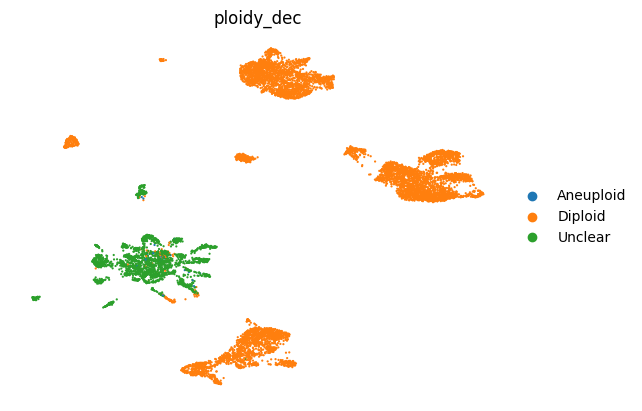

In [21]:
sc.pl.umap(
    adata,
    color="ploidy_dec",
    legend_loc="right margin",
    frameon=False,
    size=10
)

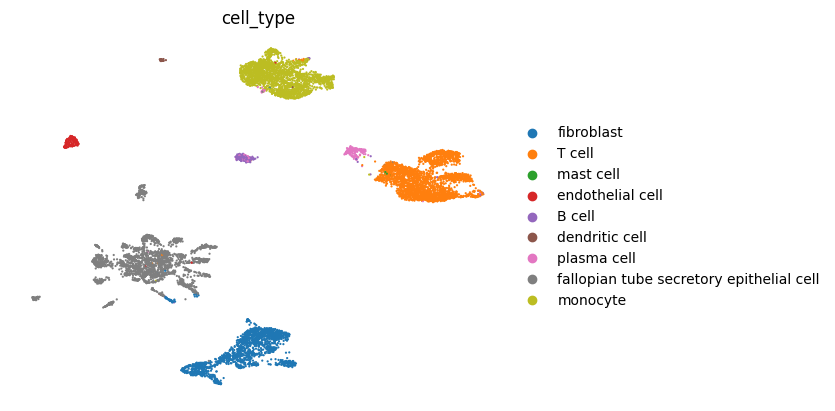

In [22]:
sc.pl.umap(
    adata,
    color="cell_type",
    legend_loc="right margin",
    frameon=False,
    size=10
)

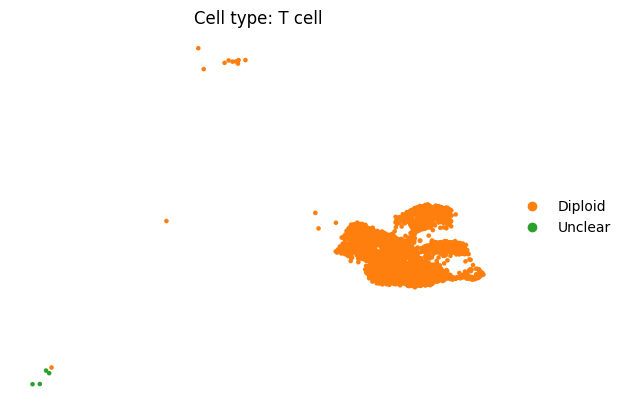

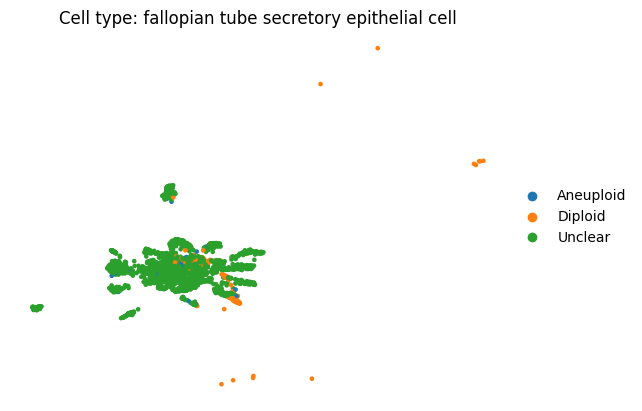

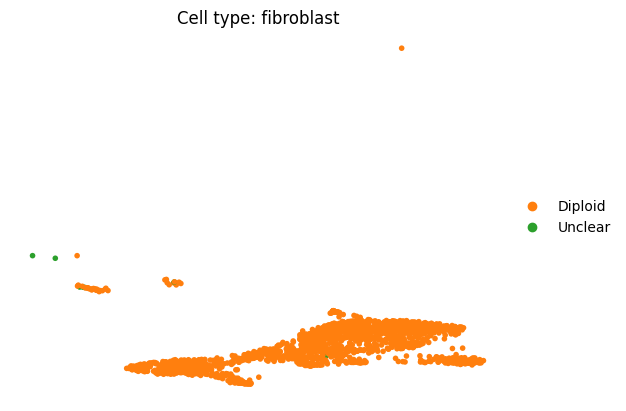

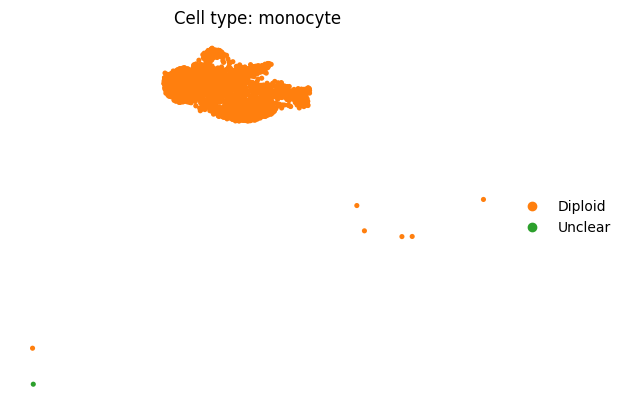

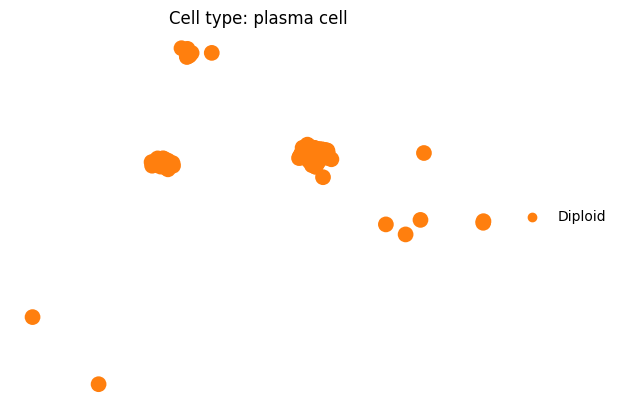

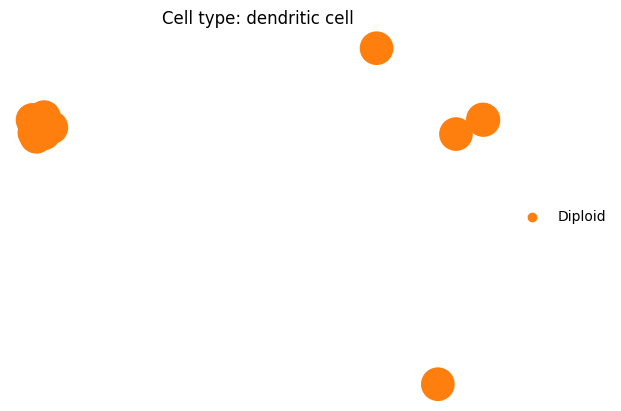

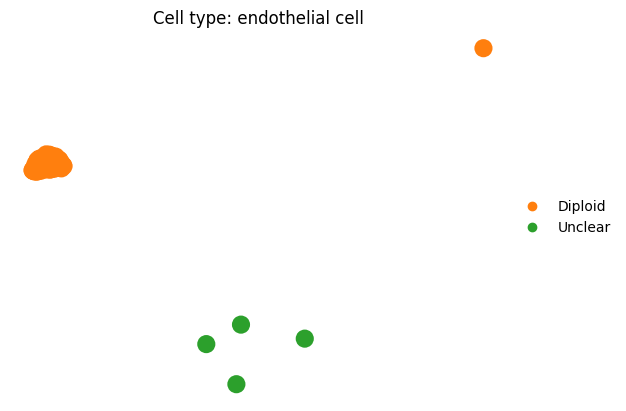

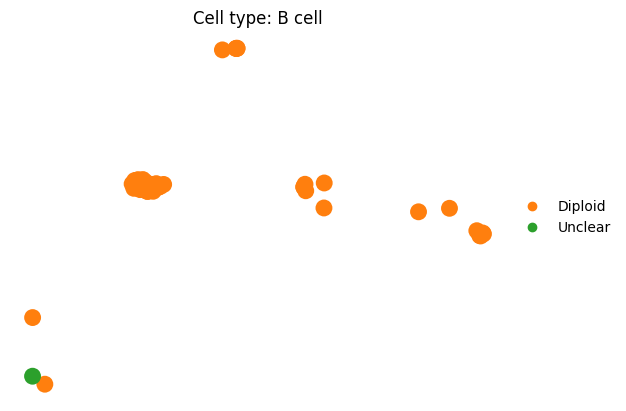

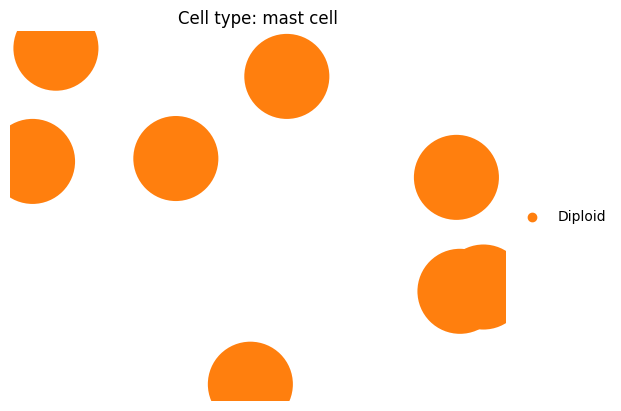

In [31]:
cell_types = adata.obs['cell_type'].unique()
for cell_type in cell_types:
    msk = adata.obs['cell_type'] == cell_type 
    adata_filt = adata[msk]
    sc.pl.umap(
        adata_filt,
        color="ploidy_dec",
        groups=None,
        title=f"Cell type: {cell_type}",
        frameon=False,
        show=False
    )

In [29]:
(adata.obs['cell_type'] == "T cell").sum()

np.int64(2764)

In [24]:
adata.obs['ploidy_dec']

cell_id
SPECTRUM-OV-070_S1_CD45P_ASCITES_CCGGTGAGTATGGAGC                 Diploid
SPECTRUM-OV-037_S1_CD45N_LEFT_OVARY_GGGATCCTCATGCGGC              Unclear
SPECTRUM-OV-054_S1_CD45P_INFRACOLIC_OMENTUM_TTGAACGTCCGCATAA      Diploid
SPECTRUM-OV-041_S1_CD45N_RIGHT_FALLOPIAN_TUBE_TGTAAGCCACATACTG    Diploid
SPECTRUM-OV-031_S1_CD45P_LEFT_FALLOPIAN_TUBE_CTCAAGAAGCACACAG     Diploid
                                                                   ...   
SPECTRUM-OV-041_S1_CD45P_RIGHT_FALLOPIAN_TUBE_CTTGATTAGGCAGTCA    Diploid
SPECTRUM-OV-054_S1_CD45N_INFRACOLIC_OMENTUM_CAGGGCTAGAGCCGAT      Diploid
SPECTRUM-OV-082_S1_CD45N_BOWEL_GTCTTTAAGAAACTAC                   Diploid
SPECTRUM-OV-009_S1_CD45P_RIGHT_OVARY_TCACTCGCATCTCGTC             Diploid
SPECTRUM-OV-071_S1_CD45P_LEFT_OVARY_AGGCATTTCCGACAGC              Diploid
Name: ploidy_dec, Length: 10199, dtype: category
Categories (3, object): ['Aneuploid', 'Diploid', 'Unclear']